# Modelagem — escola–ano (Ensino Médio)

Este notebook organiza a **etapa de Machine Learning** em quatro papéis complementares:

- **Requisito 3:** dados do ETL, EDA e pipelines (`ml/baseline_municipio.py`).
- **Requisito 4:** validação temporal (treino `<= 2017`, teste `>= 2018`) e métricas **MAE**, **RMSE**, **R²**.
- **Suite educacional (`ml/educational_ml.py`):**
  - **HistGradientBoosting** — modelo principal preditivo e ranking de risco;
  - **Árvore de decisão** — regras interpretáveis;
  - **KNN** — escolas semelhantes / benchmarking;
  - **KMeans** — segmentação de perfis (não supervisionada nas covariáveis).

**Granularidade:** `fato_integrado` — **uma linha por escola e ano**.

**Alvo (regressão supervisionada):** `taxa_abandono_em`. **Exclusão de vazamento:** não usar `indice_risco_evasao` como preditor.

## 1. Ambiente e reprodutibilidade

Execute a partir da **raiz do repositório** (para que `data/` e `ml/` resolvam corretamente). Versões recomendadas: `requirements.txt`.

### Este notebook ainda é necessário?

**Sim.** Ele continua a ser o local onde se:
- exploram os dados (EDA);
- documentam o split temporal e as métricas;
- **geram** os ficheiros em `outputs/ml/` e `outputs/figures/` que o **dashboard** lê.

A lógica dos algoritmos está nos módulos Python (`ml/baseline_municipio.py`, `ml/educational_ml.py`); o notebook é o **roteiro reprodutível** para correr essa lógica e validar resultados.

### Onde ver as alterações (algoritmos e resultados)

| O quê | Onde |
|------|------|
| Código dos regressores (HGB, árvore, KNN) e pré-processamento | `ml/baseline_municipio.py` |
| Suite completa (comparação, KMeans, vizinhos, exportação, narrativas) | `ml/educational_ml.py` |
| Tabelas CSV + JSON para storytelling | `outputs/ml/` (`escola_ano_ml_enriquecido.csv`, `ml_storytelling.json`, …) |
| Figuras (árvore, KMeans, HGB, comparação) | `outputs/figures/` (`ml_*.png`, `model_comparison_*.png`) |
| Painel para não técnicos (após gerar os artefactos acima) | Streamlit → secção **«5. Conclusoes e Modelo Preditivo»** → bloco *Apoio inteligente* (`dashboard/app.py`) |


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "ml").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from ml import baseline_municipio as bl
from ml import educational_ml as edu

## 2. Carregamento dos dados

Se `data/processed/fato_integrado.csv` não existir, o módulo **dispara o ETL automaticamente** (mesma lógica do dashboard).

In [2]:
df = bl.load_fato_integrado()
df = df.sort_values("ano").reset_index(drop=True)
print("Dimensão:", df.shape)
print("Anos:", df["ano"].min(), "—", df["ano"].max())
df.head()

Dimensão: (98, 26)
Anos: 2008 — 2022


,ano,id_municipio,id_municipio_nome,atu_ef,atu_em,had_ef,had_em,tdi_ef,tdi_em,taxa_aprovacao_ef,...,id_linha_educacional,risco_ef,risco_em,taxa_promocao_ef,taxa_promocao_em,taxa_repetencia_ef,taxa_repetencia_em,taxa_evasao_ef,taxa_evasao_em,indice_risco_evasao
0,2008,2611606,Recife,26.6,NaN,NaN,NaN,24.6,NaN,86.7,...,17,Baixo,Sem dado,70.97,64.6,9.28,7.9,12.65,27.07,18.85
1,2008,2611606,Recife,32.5,34.2,NaN,NaN,6.9,72.8,95.0,...,18,Baixo,Baixo,70.97,64.6,9.28,7.9,12.65,27.07,35.04
2,2008,2611606,Recife,20.1,37.7,NaN,NaN,6.4,9.3,95.3,...,19,Baixo,Baixo,70.97,64.6,9.28,7.9,12.65,27.07,15.99
3,2008,2611606,Recife,26.8,38.2,NaN,NaN,26.1,44.8,79.5,...,20,Moderado,Alto,70.97,64.6,9.28,7.9,12.65,27.07,26.64
4,2008,2611606,Recife,26.8,38.2,NaN,NaN,26.1,44.8,79.6,...,21,Moderado,Alto,70.97,64.6,9.28,7.9,12.65,27.07,26.64


## 3. Análise exploratória inicial

Completude, distribuição do alvo e lista de colunas numéricas vs. categóricas usadas na modelagem.

In [3]:
target = bl.TARGET
print("Taxa de valores ausentes (top 15):\n")
print(df.isna().sum().sort_values(ascending=False).head(15))

print("\n--- Estatísticas do alvo (% evasão EM) ---")
print(df[target].describe().round(3))

Taxa de valores ausentes (top 15):

had_em                31
taxa_aprovacao_em     24
taxa_reprovacao_em    24
taxa_abandono_em      24
tdi_em                19
atu_em                19
had_ef                16
taxa_reprovacao_ef     6
taxa_aprovacao_ef      6
taxa_abandono_ef       6
tdi_ef                 0
id_municipio_nome      0
atu_ef                 0
id_municipio           0
ano                    0
dtype: int64

--- Estatísticas do alvo (% evasão EM) ---
count    74.000
mean      5.828
std       7.137
min       0.000
25%       0.900
50%       1.750
75%       8.475
max      25.100
Name: taxa_abandono_em, dtype: float64


In [4]:
num_cols, cat_cols = bl.infer_feature_columns(df)
print("Features numéricas:", len(num_cols))
print(num_cols)
print("\nFeatures categóricas:", cat_cols)

Features numéricas: 19
['ano', 'id_municipio', 'atu_ef', 'atu_em', 'had_ef', 'had_em', 'tdi_ef', 'tdi_em', 'taxa_aprovacao_ef', 'taxa_aprovacao_em', 'taxa_reprovacao_ef', 'taxa_reprovacao_em', 'taxa_abandono_ef', 'taxa_promocao_ef', 'taxa_promocao_em', 'taxa_repetencia_ef', 'taxa_repetencia_em', 'taxa_evasao_ef', 'taxa_evasao_em']

Features categóricas: ['id_municipio_nome', 'periodo', 'risco_ef', 'risco_em']


## 4. Tratamento e transformação (pipeline modular)

- **Numéricas:** `SimpleImputer(median)` + `StandardScaler`  
- **Categóricas** (`periodo`): `SimpleImputer(most_frequent)` + `OneHotEncoder`  
- **Modelos:** os regressores (HistGradientBoosting, árvore, KNN) e o pré-processamento para KMeans reutilizam este bloco via `ml/baseline_municipio.py`.

A implementação está centralizada para evitar vazamento de dados (imputação ajustada só no treino).

## 5. Baseline rápido + validação temporal (requisito 4)

- **Treino:** anos `<= 2017`  
- **Teste:** anos `>= 2018`  

O baseline rápido usa **HistGradientBoosting** como modelo único (mesmas métricas). A suite completa com árvore, KNN e KMeans está na **§7**.

In [ ]:
resultado = bl.run_baseline_experiment(year_cutoff=2017)

print("Anos de treino:", resultado["train_years"])
print("Anos de teste :", resultado["test_years"])
print("n_train =", resultado["n_train"], "| n_test =", resultado["n_test"])
print()
print("--- HistGradientBoosting (modelo principal) ---")
print(resultado["metrics_hgb"])


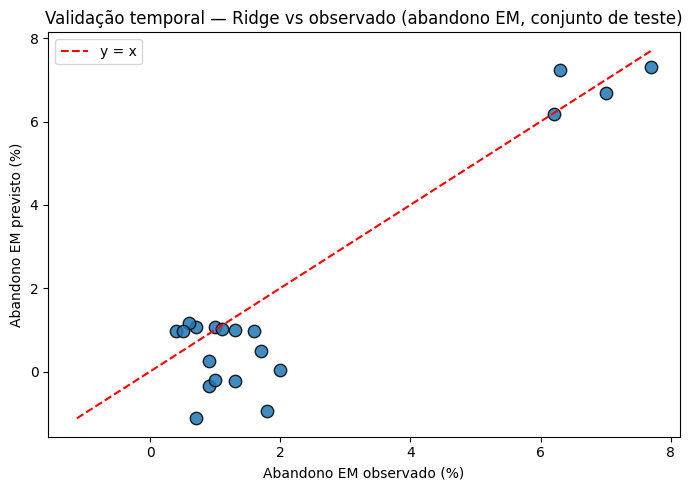

In [6]:
y_test = resultado["y_test"]
y_hat = resultado["y_pred_hgb"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_hat, s=80, alpha=0.85, edgecolors="k")
lim = min(y_test.min(), y_hat.min()), max(y_test.max(), y_hat.max())
ax.plot(lim, lim, "r--", lw=1.5, label="y = x")
ax.set_xlabel("Abandono EM observado (%)")
ax.set_ylabel("Abandono EM previsto (%)")
ax.set_title("Validação temporal — modelo principal vs observado (conjunto de teste)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Leitura dos resultados

- **MAE** em pontos percentuais: erro médio absoluto na taxa de abandono EM.
- Com **poucas linhas** no teste temporal, **R²** pode oscilar; use junto com MAE/RMSE.
- O gráfico acima mostra o **modelo principal**; na **§7** entram árvore, KNN (vizinhos) e KMeans (grupos), com exportação para o dashboard.

## 7. Suite ML educacional (papéis + artefatos)

Executa em sequência:

- **HistGradientBoosting**, **DecisionTreeRegressor**, **KNeighborsRegressor** (mesmo teste temporal; MAE, RMSE, R²);
- **importância por permutação** no modelo principal;
- **KMeans** (cotovelo, silhueta, perfis por cluster — só a partir das covariáveis transformadas).

**Saídas:** `outputs/figures/` (PNG) e `outputs/ml/` (CSV + `ml_storytelling.json`).

O **dashboard** (`streamlit run dashboard/app.py`, página 5) lê estes ficheiros e mostra textos e gráficos para apoio à decisão — rode esta célula antes de abrir o painel, ou use:

`python -c "from ml.educational_ml import run_educational_ml_suite; run_educational_ml_suite()"` na raiz do repositório.


Anos de treino: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017] | teste: [2018, 2019, 2021, 2022]
n_train = 54 | n_test = 20



,modelo,mae,rmse,r2
0,HistGradientBoosting,0.551607,0.698772,0.910543
1,Ridge,0.853852,1.108685,0.774804
2,ElasticNet,0.963377,1.218915,0.727798
3,Dummy (média),4.978333,5.450377,-4.442489


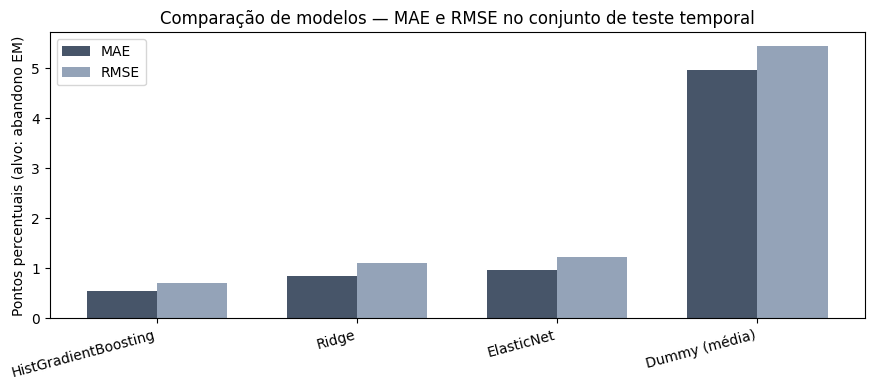

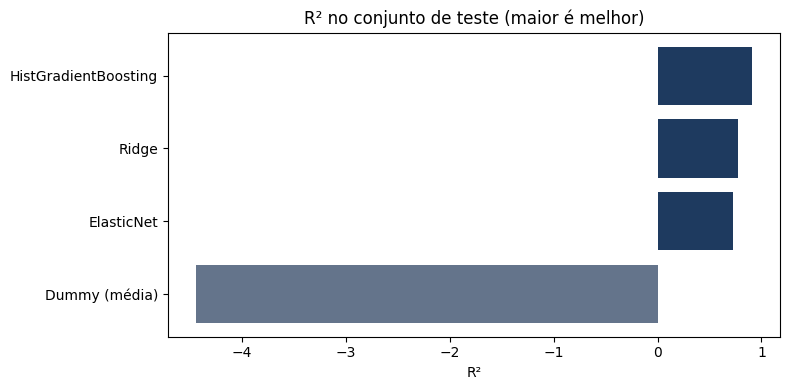

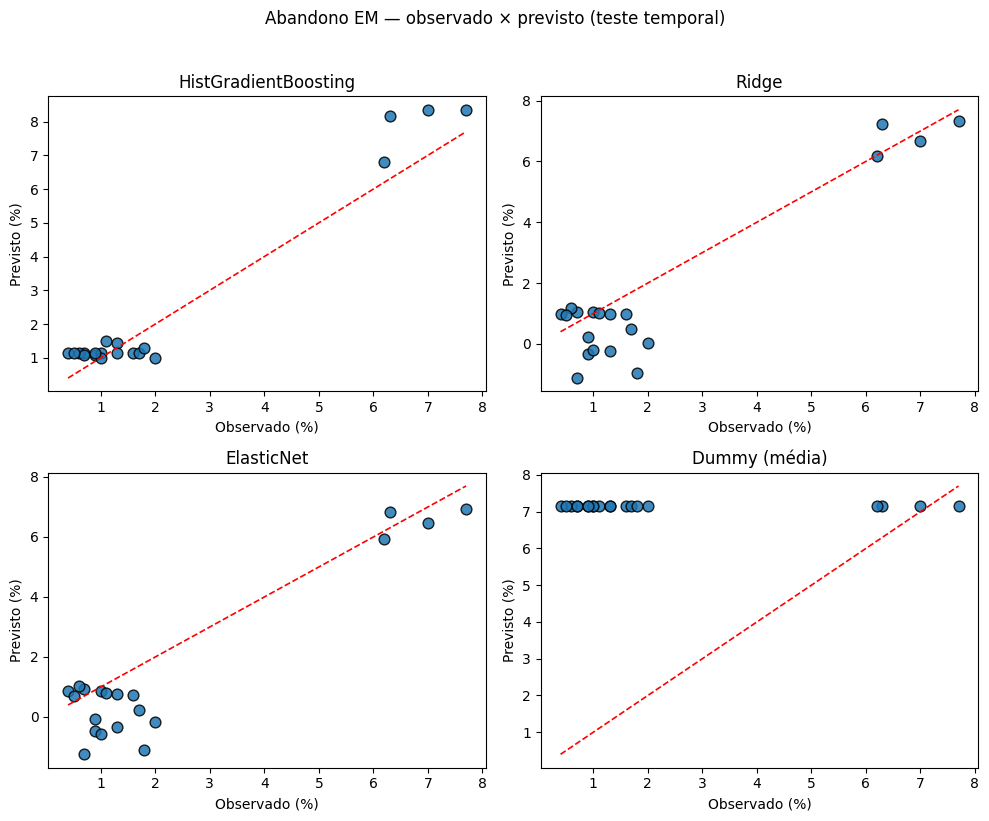

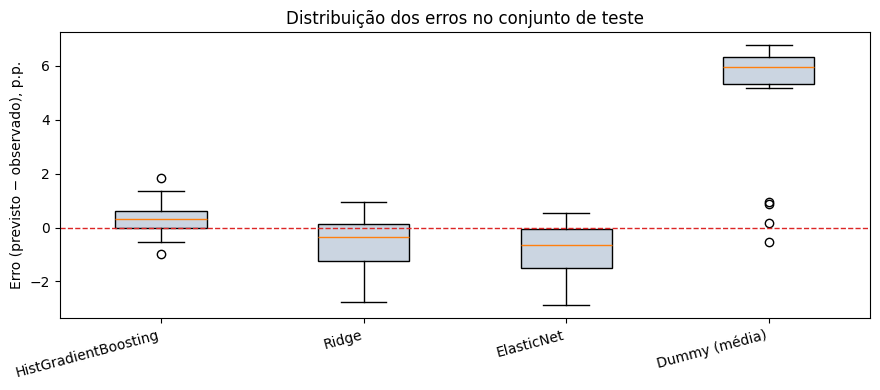

Figuras gravadas em: /home/fatima/Henrique_projetos/projeto_evasao_escolar/outputs/figures
 - /home/fatima/Henrique_projetos/projeto_evasao_escolar/outputs/figures/model_comparison_mae_rmse.png
 - /home/fatima/Henrique_projetos/projeto_evasao_escolar/outputs/figures/model_comparison_r2.png
 - /home/fatima/Henrique_projetos/projeto_evasao_escolar/outputs/figures/model_comparison_obs_vs_pred.png
 - /home/fatima/Henrique_projetos/projeto_evasao_escolar/outputs/figures/model_comparison_error_boxplot.png


In [7]:
from IPython.display import display

suite = edu.run_educational_ml_suite(
    year_cutoff=2017,
    save_artifacts=True,
    show_plots=True,
    permutation_repeats=8,
)

display(suite["metrics_table"])
print("Clusters KMeans (k):", suite["kmeans"]["n_clusters"])
print("Artefactos:", suite["artifact_dir"])
print("Figuras:", len(suite["figure_paths"]))